<a href="https://colab.research.google.com/github/nastya-kolle/cars-fuel-efficiency-regression/blob/main/Cars_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задачи:**
* построить минимум две регрессионные модели регрессии (линейную и нелинейную,
приведенную к линейной с помощью линеаризации) взаимосвязи целевого показателя
mpg и других факторов (cylinders, displacement, horsepower, weight, acceleration, model year,
origin, car name);
* сравнить качество построенных моделей;
* сделать прогноз.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import scipy
import scipy.stats as stats
import seaborn as sns

In [ ]:
cars=pd.read_csv('auto-mpg.csv')

In [ ]:
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Предоставлены данные моделей автомобилей с некоторыми их характеристиками, собранные в
1983 году в университете Карнеги-Мелон. Информация, содержащаяся в датасете:
* mpg – расход топлива (в милях на галлон);
* cylinders – число цилиндров в двигателе;
* displacement – объем двигателя (в кубических дюймах);
* horsepower – мощность (в лошадиных силах);
* weight – масса автомобиля (в фунтах);
* acceleration – разгон до 60 миль/час (в секундах);
* model year – год выпуска модели;
* origin – регион производства (1 – США, 2 – Европа, 3 – Юго-Восточная Азия);
* car name – наименование модели.


In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


**Шаг 1.** Подготовить данные для анализа:
* работа с пропусками;
* работа с дубликатами;
* обработка некорректной информации


**Шаг 2.** Определить типы данных и шкалы.

Типы данных в наборе:

*   Категориальный (категоризованный):origin,model year
*   Категориальный (некатегоризованный):car name
*   Количественный :mpg,displacement,acceleration,cylinders,horsepower,weight



In [ ]:
cars["horsepower"] = pd.to_numeric(cars["horsepower"].astype(str).str.replace(r"[^\d\-]", ""), errors="coerce")

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [ ]:
cars[cars['horsepower'].isnull()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,NaN,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,1,amc concord dl


In [ ]:
cars[cars['horsepower'].notnull()].groupby('origin').agg({'horsepower': ['mean', 'count']})

horsepower      
              mean count
origin                  
1       119.048980   245
2        80.558824    68
3        79.835443    79

In [ ]:
cars[cars['horsepower'].notnull()].groupby('model year').agg({'horsepower': ['mean', 'count']})

horsepower      
                  mean count
model year                  
70          147.827586    29
71          107.037037    27
72          120.178571    28
73          130.475000    40
74           94.230769    26
75          101.066667    30
76          101.117647    34
77          105.071429    28
78           99.694444    36
79          101.206897    29
80           77.481481    27
81           81.035714    28
82           81.466667    30

In [ ]:
cars[cars['horsepower'].notnull()].groupby('origin').agg({'horsepower': 'mean'})

,horsepower
origin,
1,119.048980
2,80.558824
3,79.835443


In [ ]:
len(cars)

398

In [ ]:
cars.loc[3,'origin']

np.int64(1)

In [ ]:
for i in range (len(cars)):
  if cars.at[i,'horsepower'] > 0:
    cars.at[i,'horsepower_new'] = cars.at[i,'horsepower']
  else:
    cars.at[i,'horsepower_new']=cars[(cars['model year']==cars.loc[i,'model year'])&(cars['horsepower'].notnull())]['horsepower'].mean()


In [ ]:
cars.iloc[2]

,2
mpg,18.0
cylinders,8
displacement,318.0
horsepower,150.0
weight,3436
acceleration,11.0
model year,70
origin,1
car name,plymouth satellite
horsepower_new,150.0


In [ ]:
cars.iloc[336]

,336
mpg,23.6
cylinders,4
displacement,140.0
horsepower,NaN
weight,2905
acceleration,14.3
model year,80
origin,1
car name,ford mustang cobra
horsepower_new,77.481481


77.481481

In [ ]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mpg             398 non-null    float64
 1   cylinders       398 non-null    int64  
 2   displacement    398 non-null    float64
 3   horsepower      392 non-null    float64
 4   weight          398 non-null    int64  
 5   acceleration    398 non-null    float64
 6   model year      398 non-null    int64  
 7   origin          398 non-null    int64  
 8   car name        398 non-null    object 
 9   horsepower_new  398 non-null    float64
dtypes: float64(5), int64(4), object(1)
memory usage: 31.2+ KB


In [ ]:
cars.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,horsepower_new
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864,104.197822
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055,38.285375
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,46.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000,76.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,92.500000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,125.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,230.000000


**Гистограмма количественных факторов**

<Axes: >

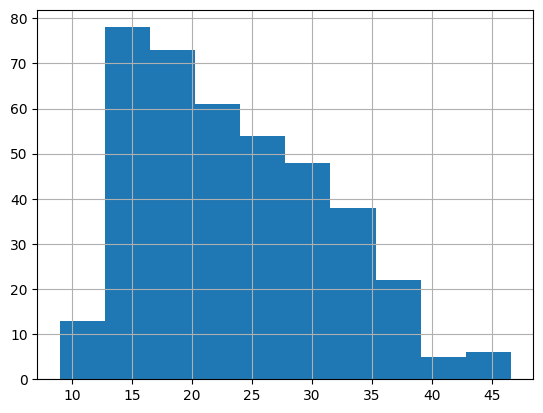

In [ ]:
cars['mpg'].hist(bins='sturges')

Строим визуализацию взаимосвязей количественных факторов

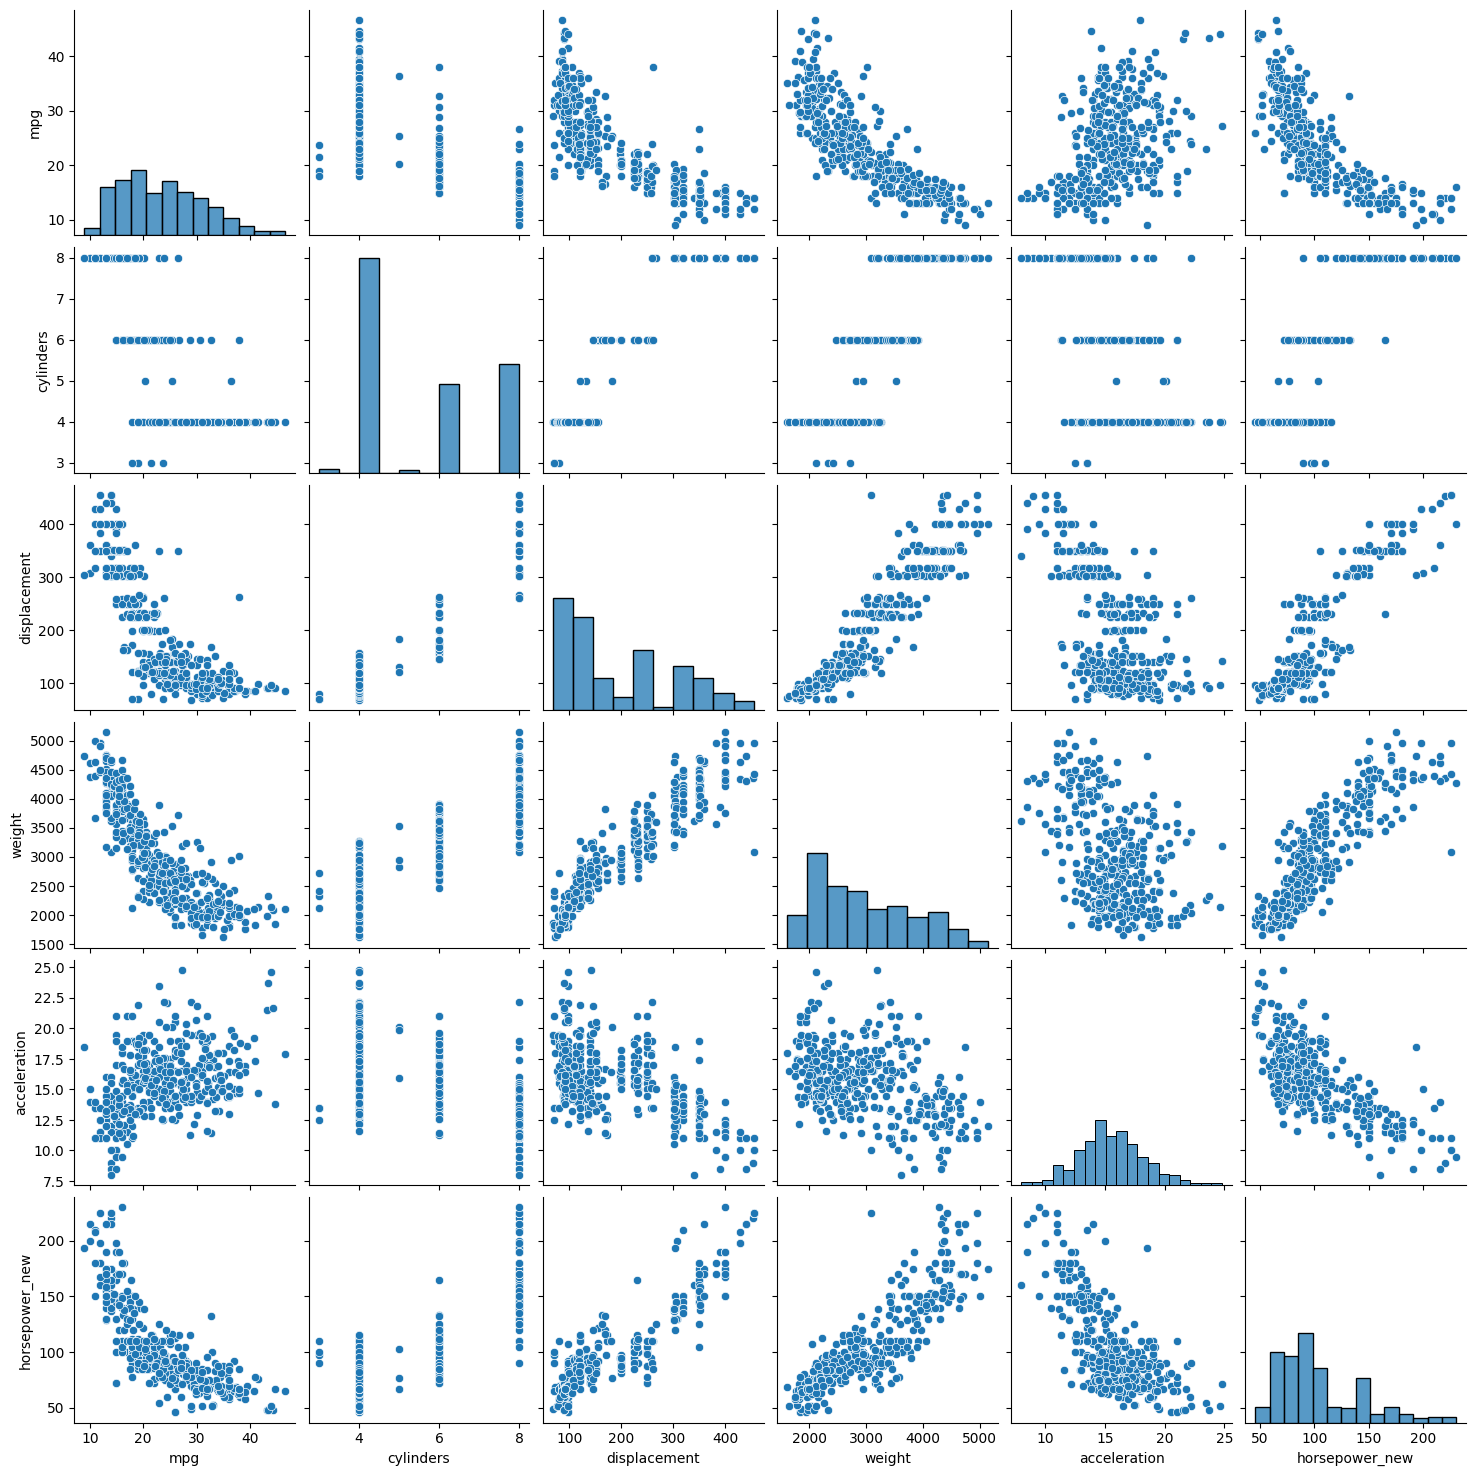

In [ ]:
col=['mpg','cylinders','displacement','weight','acceleration', 'horsepower_new']
sns.pairplot(cars.loc[:,col])

**Проверка нормальности по критерию Шапиро-Уилка**

---
Гипотеза Н0: наблюдаемая выборка принадлежит нормальной генеральной
совокупности, уровень значимости полагаем равным 0,05

In [ ]:
stats.shapiro(cars['horsepower_new'])

ShapiroResult(statistic=np.float64(0.9020526304843557), pvalue=np.float64(2.5044420727827902e-15))

In [ ]:
Norm=pd.DataFrame(columns=['p-value','Norm'], index=col)
for c in col:
  Norm.at[c,'p-value']=stats.shapiro(cars[c])[1]
  if stats.shapiro(cars[c])[1]>0.05:
    Norm.at[c,'Norm']='Normal'
  else:
    Norm.at[c,'Norm']='Unknown'
Norm

,p-value,Norm
mpg,0.0,Unknown
cylinders,0.0,Unknown
displacement,0.0,Unknown
weight,0.0,Unknown
acceleration,0.039869,Unknown
horsepower_new,0.0,Unknown


Н0 гипотеза отклоняется в пользу альтернативной. Наблюдаемая выборка не принадлежит нормальной генеральной совокупности.
Будем применять непараметрические критерии сравнения групп.

##  Анализ влияния категориальных признаков. Критерии сравнения групп

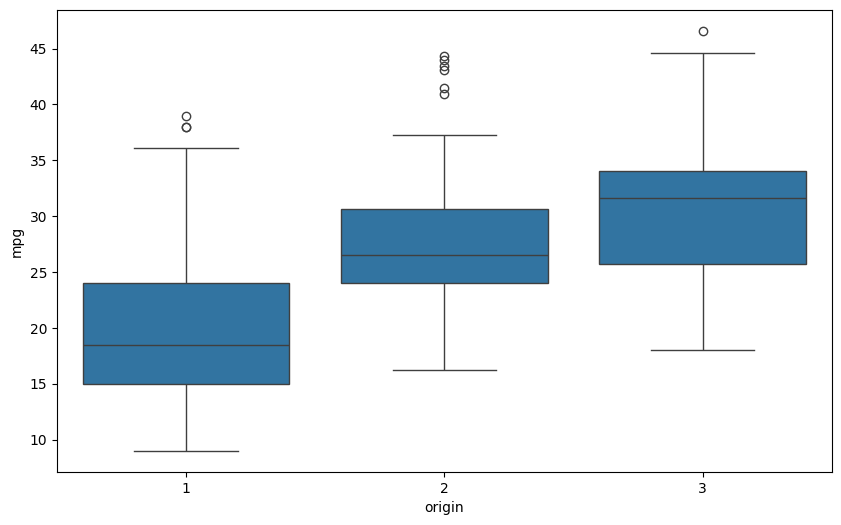

In [ ]:
f, ax=plt.subplots(figsize=(10,6))
fig=sns.boxplot(x='origin', y='mpg', data=cars)

#f, ax = plt.subplots(figsize=(10, 6))
#fig = sns.boxplot(x='Species', y='Weight', data=fish)

In [ ]:
cars.groupby('origin')['mpg'].median()

,mpg
origin,
1,18.5
2,26.5
3,31.6


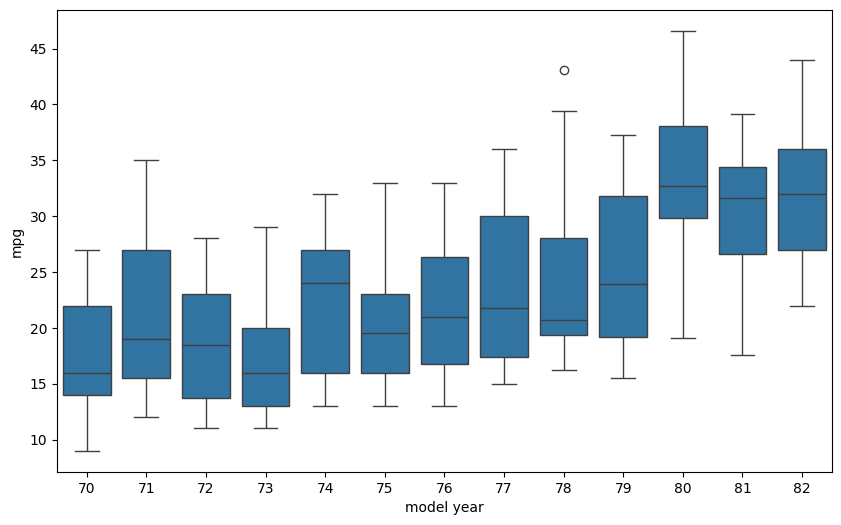

In [ ]:
f, ax=plt.subplots(figsize=(10,6))
fig=sns.boxplot(x='model year', y='mpg', data=cars)

In [ ]:
cars.groupby('model year')['mpg'].median()

,mpg
model year,
70,16.00
71,19.00
72,18.50
73,16.00
74,24.00
75,19.50
76,21.00
77,21.75
78,20.70


------------------------------------------------------------------

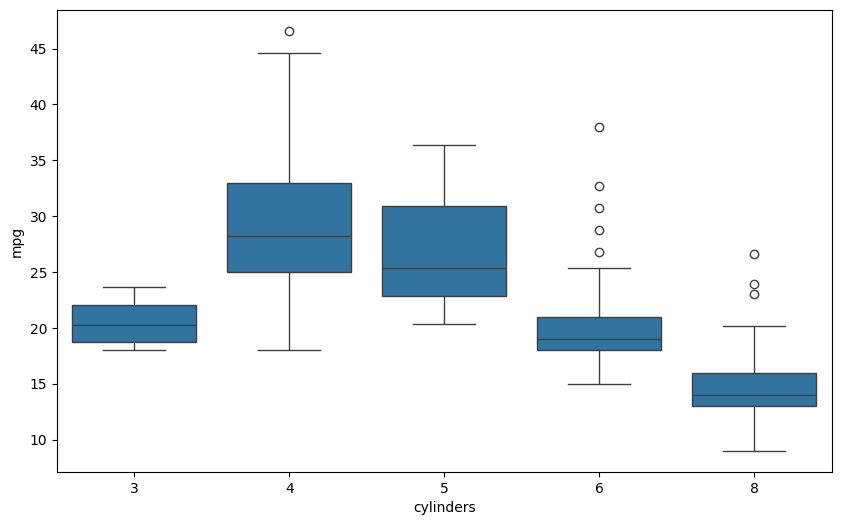

In [ ]:
f, ax=plt.subplots(figsize=(10,6))
fig=sns.boxplot(x='cylinders', y='mpg', data=cars)

-------------------------------------------------------------------------------

**Критерий Краскала-Уоллиса**

это непараметрический критерий, используется для сравнения трех или более независимых выборок.

Гипотеза Н0: медианные значения выборок не имеют статистически значимых отличий, уровень значимости полагаем равным 0,05

In [ ]:
cars1=np.array(list(cars[cars['origin']==1]['mpg']))
cars2=np.array(list(cars[cars['origin']==2]['mpg']))
cars3=np.array(list(cars[cars['origin']==3]['mpg']))

stats.mstats.kruskalwallis(cars1,cars2,cars3)

KruskalResult(statistic=np.float64(134.45665866995384), pvalue=np.float64(6.354882752621894e-30))

Медианные значения имеют статистически значимые отличия в зависимости от страны производителя. Есть взаимосвязь между страной производителя и расходом топлива

In [ ]:
cars1=np.array(list(cars[cars['model year']==70]['mpg']))
cars2=np.array(list(cars[cars['model year']==71]['mpg']))
cars3=np.array(list(cars[cars['model year']==72]['mpg']))
cars4=np.array(list(cars[cars['model year']==73]['mpg']))
cars5=np.array(list(cars[cars['model year']==74]['mpg']))
cars6=np.array(list(cars[cars['model year']==75]['mpg']))
cars7=np.array(list(cars[cars['model year']==76]['mpg']))
cars8=np.array(list(cars[cars['model year']==77]['mpg']))
cars9=np.array(list(cars[cars['model year']==78]['mpg']))
cars10=np.array(list(cars[cars['model year']==79]['mpg']))
cars11=np.array(list(cars[cars['model year']==80]['mpg']))
cars12=np.array(list(cars[cars['model year']==81]['mpg']))
cars13=np.array(list(cars[cars['model year']==82]['mpg']))

stats.mstats.kruskalwallis(cars1,cars2,cars3,cars4,cars5,cars6,cars7,cars8,cars9,cars10,cars11,cars12,cars13)

KruskalResult(statistic=np.float64(161.91212175757727), pvalue=np.float64(2.1409962726161223e-28))

Медианные значения имеют статистически значимые отличия в зависимости от года модели. Есть взаимосвязь между годом модели и расходом топлива

**Анализ взаимосвязи количественных признаков**

In [ ]:
cars[col].corr(method='pearson') # количественная корреляция Пирсона

,mpg,cylinders,displacement,weight,acceleration,horsepower_new
mpg,1.000000,-0.775396,-0.804203,-0.831741,0.420289,-0.775488
cylinders,-0.775396,1.000000,0.950721,0.896017,-0.505419,0.842340
displacement,-0.804203,0.950721,1.000000,0.932824,-0.543684,0.896191
weight,-0.831741,0.896017,0.932824,1.000000,-0.417457,0.862115
acceleration,0.420289,-0.505419,-0.543684,-0.417457,1.000000,-0.685993
horsepower_new,-0.775488,0.842340,0.896191,0.862115,-0.685993,1.000000


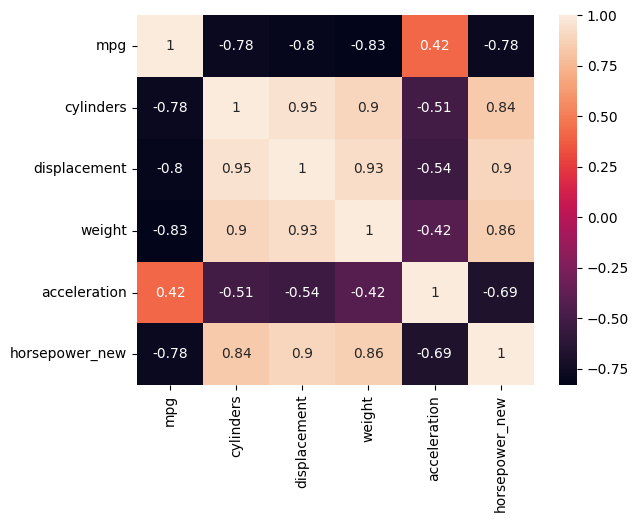

In [ ]:
sns.heatmap(cars[col].corr(),annot=True);

Есть взаимосвязь между cylinders, displacement, weight и horsepower_new


**Оценка параметров модели**

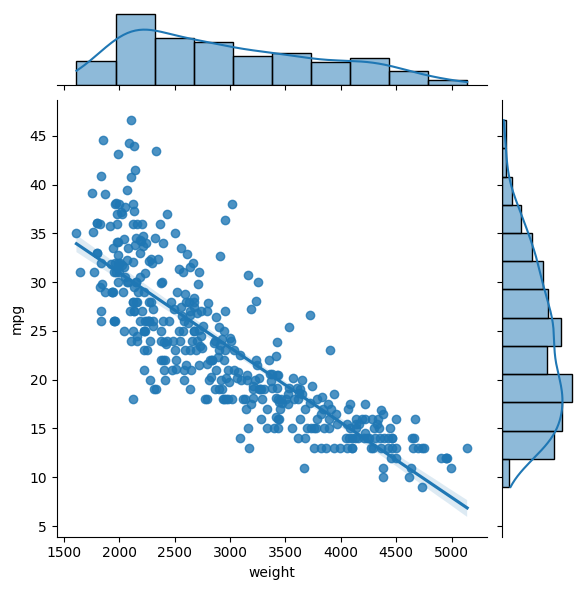

In [ ]:
sns.jointplot(x='weight', y='mpg', data=cars,kind='reg')

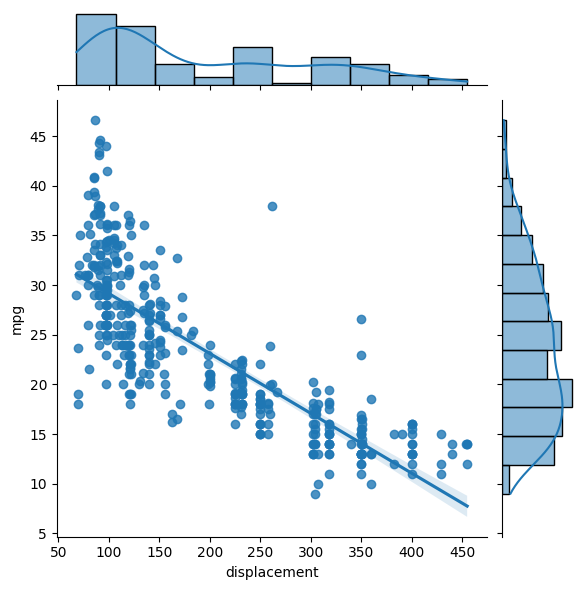

In [ ]:
sns.jointplot(x='displacement', y='mpg', data=cars,kind='reg')

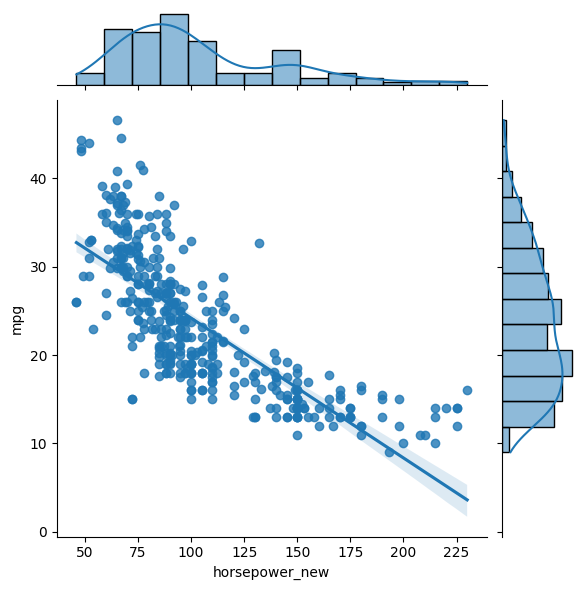

In [ ]:
sns.jointplot(x='horsepower_new', y='mpg', data=cars,kind='reg')

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
results1=smf.ols('mpg~displacement',data=cars).fit()
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     725.0
Date:                Mon, 24 Mar 2025   Prob (F-statistic):           1.66e-91
Time:                        12:12:33   Log-Likelihood:                -1175.5
No. Observations:                 398   AIC:                             2355.
Df Residuals:                     396   BIC:                             2363.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       35.1748      0.492     71.519      0.000      34.208      36.142
displacement    -0.0603      0.002    -26.926      0.000      -0.065      -0.056
==============================================================================
Omnibus:                       41.373   Durbin-Watson:                   0.919
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               60.024
Skew:                           0.711   Prob(JB):                     9.24e-14
Kurtosis:                       4.264   Cond. No.                         463.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

* R-squared:	0.647 -64 % наблюдений обьема двигателя обьясняют расход топлива
* F-statistic:	725.0
* Prob (F-statistic):	1.66e-91 модель регресии статистически значима
* std err 0.492 0.002 -насколько значения удалены от прямой
* t значение статистики Стьдента, если не равен 0, то данный признак значим
* P>|t|-p-value если меньше 0.05, то данный признак значим
* [0.025	0.975] 34.208	36.142 -0.065	-0.056 -доверительный интервал, если не содержит 0, то признак значим

Соответствуют ли остатки нормальному закону распределения, коррелированы или нет

* Omnibus:	41.373 проверяет на нормальность на основе Skew:	0.711	(коэффициент ассиметрии)- у нормальной выборки близко к 0, Kurtosis:	4.264 (коэффициент эксцесса) - унормального распределения равно 3
* Prob(Omnibus):	0.000, Prob(JB):	9.24e-14 -значения p-value близки к 0, предположение о нормальном распределении отвергается
* Durbin-Watson:	0.919 -критерий коррелированности остатков , если значение близко к 2, то коррелированы, в иных случаях зависимы

In [ ]:
results_1=smf.ols('mpg~weight',data=cars).fit()
results_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     888.9
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          2.97e-103
Time:                        12:12:35   Log-Likelihood:                -1148.4
No. Observations:                 398   AIC:                             2301.
Df Residuals:                     396   BIC:                             2309.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.3174      0.795     58.243      0.000      44.754      47.881
weight        -0.0077      0.000    -29.814      0.000      -0.008      -0.007
==============================================================================
Omnibus:                       40.423   Durbin-Watson:                   0.797
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               56.695
Skew:                           0.713   Prob(JB):                     4.89e-13
Kurtosis:                       4.176   Cond. No.                     1.13e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

* R-squared:	0.692 -69 % наблюдений обьема двигателя обьясняют расход топлива
* F-statistic:	888.9
* Prob (F-statistic):	2.97e-103 модель регресии статистически значима
* std err	0.795 0.000 -насколько значения удалены от прямой
* t значение статистики Стьдента, если не равен 0, то данный признак значим
* P>|t|-p-value если меньше 0.05, то данный признак значим
* [0.025	0.975] 44.754	47.881 -0.008	-0.007 -доверительный интервал, если не содержит 0, то признак значим

Соответствуют ли остатки нормальному закону распределения, коррелированы или нет

* Omnibus:	40.423 проверяет на нормальность на основе Skew:	0.713	(коэффициент ассиметрии)- у нормальной выборки близко к 0, Kurtosis:	4.176 (коэффициент эксцесса) - унормального распределения равно 3
* Prob(Omnibus):	0.000, Prob(JB):	4.89e-13 -значения p-value близки к 0, предположение о нормальном распределении отвергается
* Durbin-Watson:	0.797 -критерий коррелированности остатков , если значение близко к 2, то коррелированы, в иных случаях зависимы

In [ ]:
results_1=smf.ols('mpg~horsepower_new',data=cars).fit()
results_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     597.4
Date:                Mon, 24 Mar 2025   Prob (F-statistic):           4.20e-81
Time:                        12:12:36   Log-Likelihood:                -1199.6
No. Observations:                 398   AIC:                             2403.
Df Residuals:                     396   BIC:                             2411.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         40.0108      0.719     55.655      0.000      38.597      41.424
horsepower_new    -0.1583      0.006    -24.442      0.000      -0.171      -0.146
==============================================================================
Omnibus:                       17.516   Durbin-Watson:                   0.923
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.574
Skew:                           0.509   Prob(JB):                     9.26e-05
Kurtosis:                       3.290   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Степенная: $Y=ax^bɛ$

Логарифмирование: $\ln Y=\ln(ax^bɛ)$ => $\ln Y=\ln a+b\ln x+\ln ɛ$

Замена: $Y_1=\ln Y$, $x_1=\ln x$

Что получим: $Y_1=\ln a+bx_1+\ln ɛ$

In [ ]:
cars['mpg1']=np.log(cars['mpg'])
cars['displacement1']=np.log(cars['displacement'])
cars['weight1']=np.log(cars['weight'])
cars['horsepower_new1']=np.log(cars['horsepower_new'])

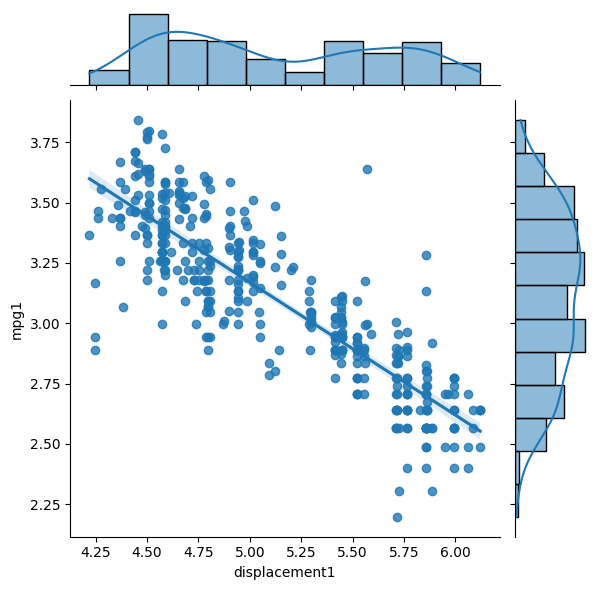

In [ ]:
sns.jointplot(x='displacement1', y='mpg1', data=cars,kind='reg')

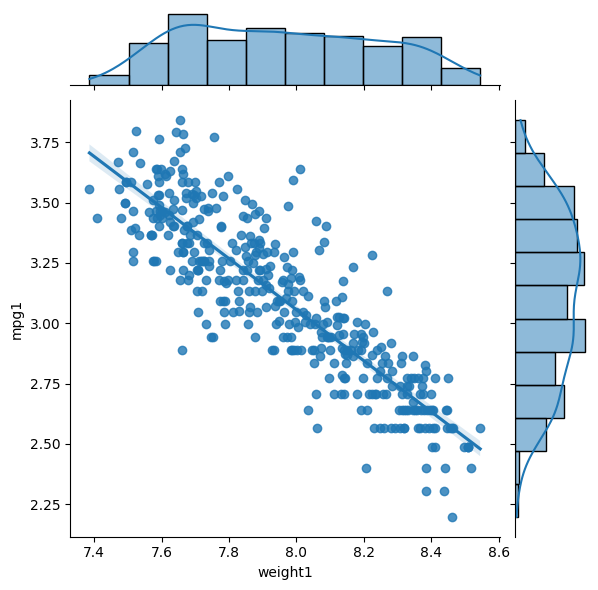

In [ ]:
sns.jointplot(x='weight1',y='mpg1',data=cars,kind='reg')

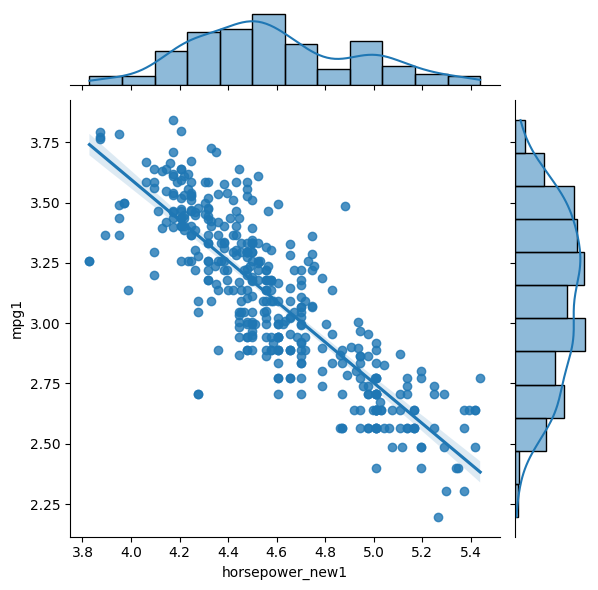

In [ ]:
sns.jointplot(x='horsepower_new1',y='mpg1',data=cars,kind='reg')

In [ ]:
result2=smf.ols('mpg1~displacement1',data=cars).fit()
result2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mpg1   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     1131.
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          4.31e-118
Time:                        12:13:13   Log-Likelihood:                 134.06
No. Observations:                 398   AIC:                            -264.1
Df Residuals:                     396   BIC:                            -256.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.9201      0.084     70.245      0.000       5.754       6.086
displacement1    -0.5502      0.016    -33.624      0.000      -0.582      -0.518
==============================================================================
Omnibus:                       20.472   Durbin-Watson:                   0.918
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               57.099
Skew:                          -0.077   Prob(JB):                     3.99e-13
Kurtosis:                       4.849   Cond. No.                         51.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
result_2=smf.ols('mpg1~weight1', data=cars).fit()
result_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mpg1   R-squared:                       0.765
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     1287.
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          1.75e-126
Time:                        12:13:14   Log-Likelihood:                 153.46
No. Observations:                 398   AIC:                            -302.9
Df Residuals:                     396   BIC:                            -294.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.5219      0.235     49.056      0.000      11.060      11.984
weight1       -1.0583      0.029    -35.874      0.000      -1.116      -1.000
==============================================================================
Omnibus:                       10.762   Durbin-Watson:                   0.765
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               13.126
Skew:                           0.275   Prob(JB):                      0.00141
Kurtosis:                       3.699   Cond. No.                         230.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
result_2=smf.ols('mpg1~horsepower_new1', data=cars).fit()
result_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mpg1   R-squared:                       0.719
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     1014.
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          2.97e-111
Time:                        12:13:15   Log-Likelihood:                 118.25
No. Observations:                 398   AIC:                            -232.5
Df Residuals:                     396   BIC:                            -224.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           6.9695      0.122     57.217      0.000       6.730       7.209
horsepower_new1    -0.8435      0.026    -31.843      0.000      -0.896      -0.791
==============================================================================
Omnibus:                        5.654   Durbin-Watson:                   1.105
Prob(Omnibus):                  0.059   Jarque-Bera (JB):                7.293
Skew:                          -0.102   Prob(JB):                       0.0261
Kurtosis:                       3.631   Cond. No.                         64.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
result3=smf.ols('mpg1~displacement1+origin',data=cars).fit()
result3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mpg1   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     565.1
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          1.31e-116
Time:                        12:13:16   Log-Likelihood:                 134.39
No. Observations:                 398   AIC:                            -262.8
Df Residuals:                     395   BIC:                            -250.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.9994      0.129     46.431      0.000       5.745       6.253
displacement1    -0.5620      0.022    -25.589      0.000      -0.605      -0.519
origin           -0.0118      0.015     -0.810      0.418      -0.040       0.017
==============================================================================
Omnibus:                       19.915   Durbin-Watson:                   0.921
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               55.159
Skew:                          -0.054   Prob(JB):                     1.05e-12
Kurtosis:                       4.821   Cond. No.                         82.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
result_3=smf.ols('mpg1~weight1+origin',data=cars).fit()
result_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mpg1   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     646.7
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          2.51e-125
Time:                        12:13:51   Log-Likelihood:                 154.61
No. Observations:                 398   AIC:                            -303.2
Df Residuals:                     395   BIC:                            -291.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.2212      0.307     36.535      0.000      10.617      11.825
weight1       -1.0244      0.037    -27.697      0.000      -1.097      -0.952
origin         0.0196      0.013      1.516      0.130      -0.006       0.045
==============================================================================
Omnibus:                        9.565   Durbin-Watson:                   0.767
Prob(Omnibus):                  0.008   Jarque-Bera (JB):               11.468
Skew:                           0.254   Prob(JB):                      0.00323
Kurtosis:                       3.658   Cond. No.                         306.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
result3=smf.ols('mpg1~horsepower_new1+origin',data=cars).fit()
result3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mpg1   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     589.0
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          2.99e-119
Time:                        12:13:52   Log-Likelihood:                 140.52
No. Observations:                 398   AIC:                            -275.0
Df Residuals:                     395   BIC:                            -263.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           6.4082      0.142     45.272      0.000       6.130       6.686
horsepower_new1    -0.7496      0.029    -26.223      0.000      -0.806      -0.693
origin              0.0832      0.012      6.839      0.000       0.059       0.107
==============================================================================
Omnibus:                        2.111   Durbin-Watson:                   1.172
Prob(Omnibus):                  0.348   Jarque-Bera (JB):                2.085
Skew:                           0.029   Prob(JB):                        0.353
Kurtosis:                       3.350   Cond. No.                         83.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
result3=smf.ols('mpg1~horsepower_new1+weight1+origin',data=cars).fit()
result3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mpg1   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     523.5
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          4.89e-137
Time:                        12:13:53   Log-Likelihood:                 185.27
No. Observations:                 398   AIC:                            -362.5
Df Residuals:                     394   BIC:                            -346.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           9.6225      0.346     27.774      0.000       8.941      10.304
horsepower_new1    -0.3710      0.046     -8.100      0.000      -0.461      -0.281
weight1            -0.6119      0.061     -9.968      0.000      -0.733      -0.491
origin              0.0311      0.012      2.575      0.010       0.007       0.055
==============================================================================
Omnibus:                        2.821   Durbin-Watson:                   0.958
Prob(Omnibus):                  0.244   Jarque-Bera (JB):                2.852
Skew:                           0.089   Prob(JB):                        0.240
Kurtosis:                       3.374   Cond. No.                         432.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

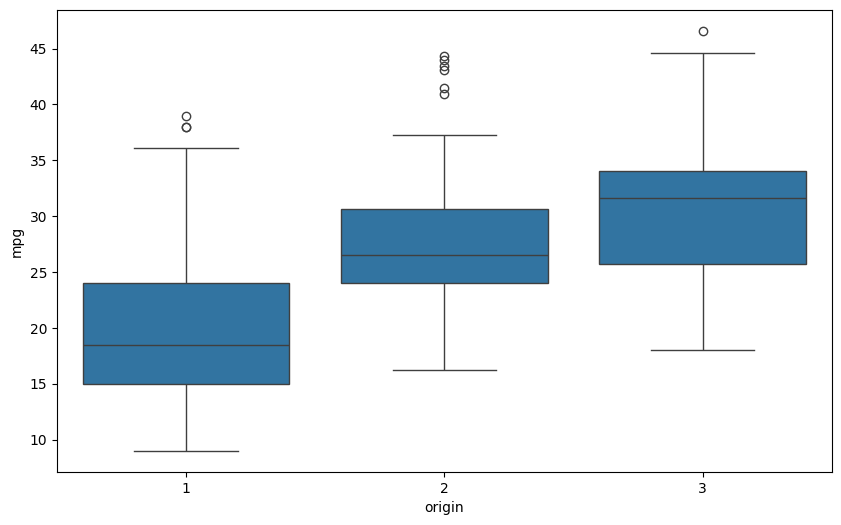

In [ ]:
f,ax=plt.subplots(figsize=(10,6))
fig=sns.boxplot(x='origin', y='mpg', data=cars)

In [ ]:
cars1=cars[cars['origin']==2]['mpg']
cars2=cars[cars['origin']==3]['mpg']
scipy.stats.mannwhitneyu(cars1, cars2)

MannwhitneyuResult(statistic=np.float64(2027.0), pvalue=np.float64(0.005010500309130046))

In [ ]:
result4=smf.ols('mpg1~weight1+displacement',data=cars).fit()
result4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mpg1   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     703.7
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          6.32e-131
Time:                        12:13:56   Log-Likelihood:                 167.60
No. Observations:                 398   AIC:                            -329.2
Df Residuals:                     395   BIC:                            -317.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        8.8767      0.540     16.427      0.000       7.814       9.939
weight1         -0.7003      0.072     -9.697      0.000      -0.842      -0.558
displacement    -0.0010      0.000     -5.394      0.000      -0.001      -0.001
==============================================================================
Omnibus:                       13.195   Durbin-Watson:                   0.793
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               19.401
Skew:                           0.257   Prob(JB):                     6.12e-05
Kurtosis:                       3.952   Cond. No.                     1.50e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.5e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
result4=smf.ols('mpg1~weight1+displacement1',data=cars).fit()
result4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   mpg1   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     686.1
Date:                Mon, 24 Mar 2025   Prob (F-statistic):          3.09e-129
Time:                        12:13:57   Log-Likelihood:                 163.68
No. Observations:                 398   AIC:                            -321.4
Df Residuals:                     395   BIC:                            -309.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         9.6341      0.473     20.371      0.000       8.704      10.564
weight1          -0.6871      0.086     -7.963      0.000      -0.857      -0.517
displacement1    -0.2080      0.046     -4.563      0.000      -0.298      -0.118
==============================================================================
Omnibus:                       13.604   Durbin-Watson:                   0.793
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               22.589
Skew:                           0.217   Prob(JB):                     1.24e-05
Kurtosis:                       4.084   Cond. No.                         569.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

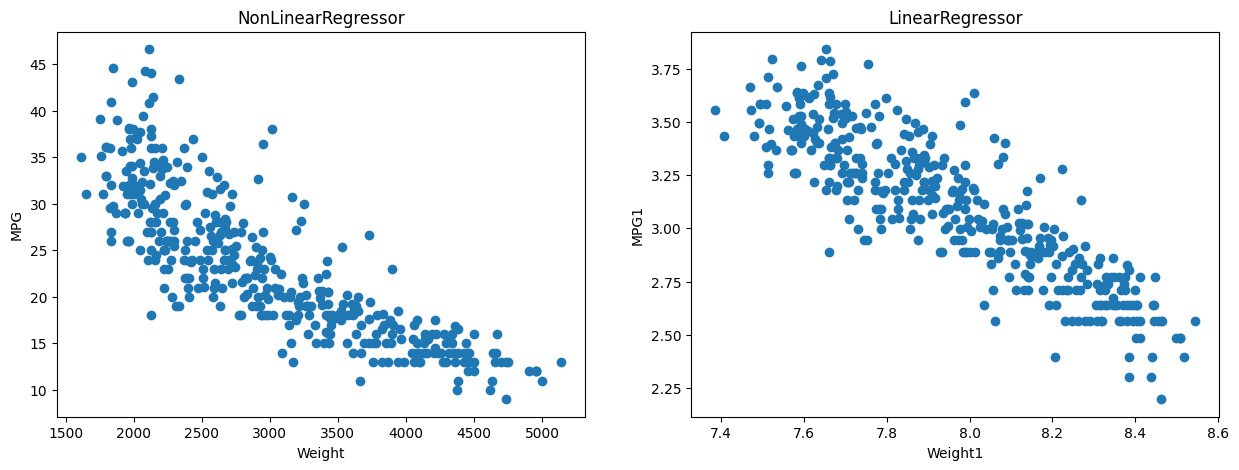

In [ ]:
fig, (ax1, ax2)=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
ax1.scatter(x=cars['weight'], y=cars['mpg'])
ax1.set_title('NonLinearRegressor')
ax1.set_xlabel('Weight')
ax1.set_ylabel('MPG')

ax2.scatter(x=cars['weight1'], y=cars['mpg1'])
ax2.set_title('LinearRegressor')
ax2.set_xlabel('Weight1')
ax2.set_ylabel('MPG1')

plt.show()

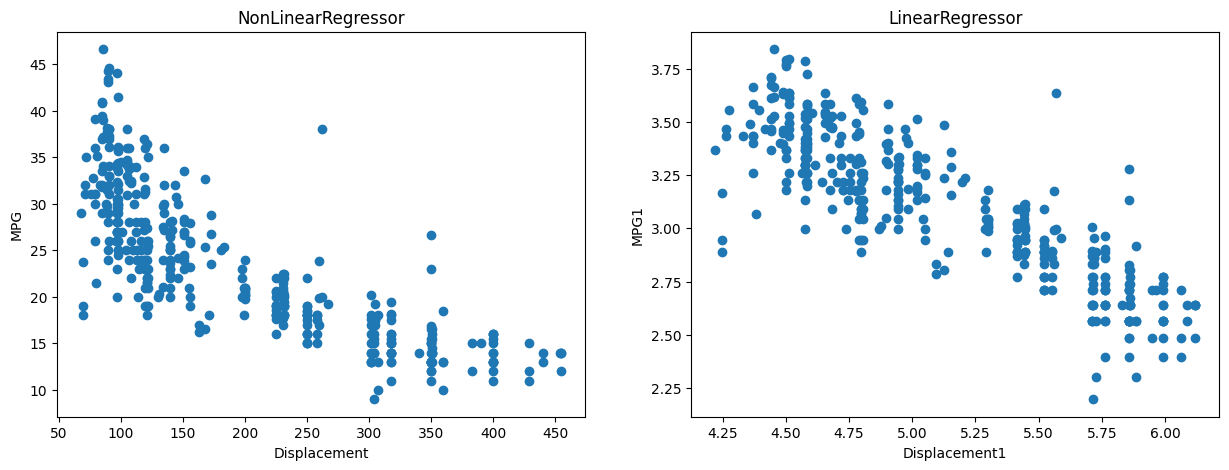

In [ ]:
fig, (ax1, ax2)=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
ax1.scatter(x=cars['displacement'], y=cars['mpg'])
ax1.set_title('NonLinearRegressor')
ax1.set_xlabel('Displacement')
ax1.set_ylabel('MPG')

ax2.scatter(x=cars['displacement1'], y=cars['mpg1'])
ax2.set_title('LinearRegressor')
ax2.set_xlabel('Displacement1')
ax2.set_ylabel('MPG1')

plt.show()

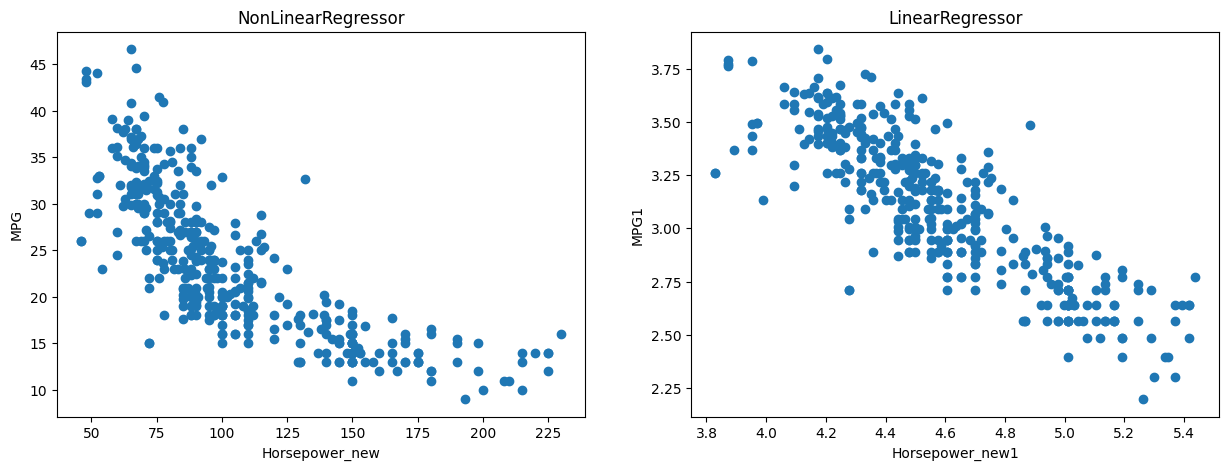

In [ ]:
fig, (ax1, ax2)=plt.subplots(nrows=1,ncols=2,figsize=(15,5))
ax1.scatter(x=cars['horsepower_new'], y=cars['mpg'])
ax1.set_title('NonLinearRegressor')
ax1.set_xlabel('Horsepower_new')
ax1.set_ylabel('MPG')

ax2.scatter(x=cars['horsepower_new1'], y=cars['mpg1'])
ax2.set_title('LinearRegressor')
ax2.set_xlabel('Horsepower_new1')
ax2.set_ylabel('MPG1')

plt.show()

**Линейная регрессия**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

In [ ]:
Y1=cars['mpg']#зависимая (целевая) переменная
X1=cars[['weight','horsepower_new','origin']]#независимые факторы
X1_train, X1_test, Y1_train, Y1_test=train_test_split(X1, Y1,test_size=0.2,random_state=0)

In [ ]:
print('Number of data :', cars.shape[0])
print('Number of train data :',X1_train.shape[0])
print('Number of test data :', X1_test.shape[0])

Number of data : 398
Number of train data : 318
Number of test data : 80


In [ ]:
import sklearn.linear_model as lm

In [ ]:
LR=lm.LinearRegression()

In [ ]:
model1=LR.fit(X1_train, Y1_train)

In [ ]:
Y1_train_pred=model1.predict(X1_train)
Y1_test_pred=model1.predict(X1_test)

In [ ]:
QualityMetrics=['R2 train', 'R2 test', 'MSE train', 'MSE test']
Models=pd.DataFrame(index=QualityMetrics)
Models.at[QualityMetrics,'LinearRegressor']=[r2_score(Y1_train, Y1_train_pred),
                                             r2_score(Y1_test, Y1_test_pred),
                                             mean_squared_error(Y1_train, Y1_train_pred),
                                             mean_squared_error(Y1_test, Y1_test_pred)]

In [ ]:
Models

,LinearRegressor
R2 train,0.717131
R2 test,0.712556
MSE train,17.052417
MSE test,18.240470


**Нелинейная регрессия**

In [ ]:
Y2=cars['mpg1']
X2=cars[['weight1', 'horsepower_new1','origin']]
X2_train, X2_test, Y2_train, Y2_test=train_test_split(X2, Y2, test_size=0.2, random_state=0)
model2=LR.fit(X2_train, Y2_train)
Y2_train_pred=model2.predict(X2_train)
Y2_test_pred=model2.predict(X2_test)
Models.at[QualityMetrics, 'NonLinearRegressor']=[r2_score(Y2_train, Y2_train_pred),
                                                 r2_score(Y2_test, Y2_test_pred),
                                                 mean_squared_error(np.exp(Y2_train), np.exp(Y2_train_pred)),
                                                 mean_squared_error(np.exp(Y2_test), np.exp(Y2_test_pred))]

In [ ]:
Models

,LinearRegressor,NonLinearRegressor
R2 train,0.717131,0.799115
R2 test,0.712556,0.794545
MSE train,17.052417,15.454607
MSE test,18.240470,16.634592


In [ ]:
Y4=cars['mpg']
X4=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]
X4_train, X4_test, Y4_train, Y4_test=train_test_split(X4, Y4, test_size=0.2, random_state=0)
model4=LR.fit(X4_train, Y4_train)
Y4_train_pred=model4.predict(X4_train)
Y4_test_pred=model4.predict(X4_test)
Models.at[QualityMetrics, 'LinearRegressor_full']=[r2_score(Y4_train, Y4_train_pred),
                                                 r2_score(Y4_test, Y4_test_pred),
                                                 mean_squared_error(Y4_train, Y4_train_pred),
                                                 mean_squared_error(Y4_test, Y4_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full
R2 train,0.717131,0.799115,0.818790
R2 test,0.712556,0.794545,0.820529
MSE train,17.052417,15.454607,10.923995
MSE test,18.240470,16.634592,11.388753


In [ ]:
Y3=cars['mpg1']
X3=cars[['weight1', 'displacement1','horsepower_new1','origin','cylinders', 'acceleration', 'model year']]
X3_train, X3_test, Y3_train, Y3_test=train_test_split(X3, Y3, test_size=0.2, random_state=0)
model3=LR.fit(X3_train, Y3_train)
Y3_train_pred=model3.predict(X3_train)
Y3_test_pred=model3.predict(X3_test)
Models.at[QualityMetrics, 'NonLinearRegressor_full']=[r2_score(Y3_train, Y3_train_pred),
                                                 r2_score(Y3_test, Y3_test_pred),
                                                 mean_squared_error(np.exp(Y3_train), np.exp(Y3_train_pred)),
                                                 mean_squared_error(np.exp(Y3_test), np.exp(Y3_test_pred))]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full
R2 train,0.717131,0.799115,0.818790,0.887542
R2 test,0.712556,0.794545,0.820529,0.893278
MSE train,17.052417,15.454607,10.923995,8.148694
MSE test,18.240470,16.634592,11.388753,7.701879


## Прогноз

# Линейная регрессия с аргументами
Y1=cars['mpg']#зависимая (целевая) переменная


X1=cars[['weight','horsepower_new','origin']]#независимые факторы

In [ ]:
model1=LR.fit(X1_train, Y1_train)
model1.intercept_,model1.coef_

(np.float64(40.50297660578212), array([-0.00414667, -0.06771484,  1.48683123]))

In [ ]:
list(zip(X1_train.columns,model1.coef_))

[('weight', np.float64(-0.0041466658984804575)),
 ('horsepower_new', np.float64(-0.06771483868163414)),
 ('origin', np.float64(1.4868312314599403))]

In [ ]:
cars.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,horsepower_new,mpg1,displacement1,weight1,horsepower_new1
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864,104.197822,3.101384,5.123174,7.956890,4.585887
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055,38.285375,0.339656,0.531279,0.280665,0.341487
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,46.000000,2.197225,4.219508,7.385851,3.828641
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000,76.000000,2.862201,4.646783,7.706950,4.330733
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,92.500000,3.135494,5.000443,7.938623,4.527194
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,125.000000,3.367296,5.568345,8.190909,4.828314
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,230.000000,3.841601,6.120297,8.544808,5.438079


In [ ]:
x_new_car=[[3000,100,2]]
y_new_car=model1.predict(x_new_car)
Models.at['Forecast','LinearRegressor']=y_new_car.round(2)[0]
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа ',y_new_car.round(2)[0])

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа  24.27


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full
R2 train,0.717131,0.799115,0.818790,0.887542
R2 test,0.712556,0.794545,0.820529,0.893278
MSE train,17.052417,15.454607,10.923995,8.148694
MSE test,18.240470,16.634592,11.388753,7.701879
Forecast,24.270000,21.760000,24.560000,NaN


# Нелинейная регрессия с аргументами (с помощью линеаризации)

Y2=cars['mpg1']


X2=cars[['weight1', 'horsepower_new1','origin']]

In [ ]:
model2=LR.fit(X2_train, Y2_train)
model2.intercept_, model2.coef_

(np.float64(9.20825858639928), array([-0.5227333 , -0.43631722,  0.03326008]))

In [ ]:
list(zip(X2_train.columns,model2.coef_))

[('weight1', np.float64(-0.5227332991593324)),
 ('horsepower_new1', np.float64(-0.4363172240564151)),
 ('origin', np.float64(0.03326007965035288))]

In [ ]:
x_new_car=[[np.log(3000),np.log(100),2]]
y_new_car=model2.predict(x_new_car)
y_new_car=math.exp(y_new_car)
Models.at['Forecast','NonLinearRegressor']=round(y_new_car,2)
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа ',round(y_new_car,2))

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа  21.76


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
<ipython-input-91-896127c23359>:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_new_car=math.exp(y_new_car)


In [ ]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full
R2 train,0.717131,0.799115,0.818790,0.887542
R2 test,0.712556,0.794545,0.820529,0.893278
MSE train,17.052417,15.454607,10.923995,8.148694
MSE test,18.240470,16.634592,11.388753,7.701879
Forecast,24.270000,21.760000,24.560000,NaN


## Линейная регрессия с аргументами

Y4=cars['mpg']


X4=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]

In [ ]:
model4=LR.fit(X4_train, Y4_train)
model4.intercept_,model4.coef_

(np.float64(-19.61056155671188),
 array([-0.00647803, -0.01875966,  1.56769795,  0.02123963, -0.38972667,
         0.20028901,  0.74521654]))

In [ ]:
list(zip(X4_train.columns,model4.coef_))

[('weight', np.float64(-0.006478027855813251)),
 ('horsepower_new', np.float64(-0.01875965504820113)),
 ('origin', np.float64(1.5676979523021206)),
 ('displacement', np.float64(0.02123963166626582)),
 ('cylinders', np.float64(-0.3897266698748555)),
 ('acceleration', np.float64(0.20028900836605268)),
 ('model year', np.float64(0.745216544711412))]

In [ ]:
x_new_car=[[3000,100,2,200,5,17,76]]
y_new_car=model4.predict(x_new_car)
Models.at['Forecast','LinearRegressor_full']=y_new_car.round(2)[0]
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100, страной производителем -Европа, обьемом двигателя 200, количеством цилиндров в двигателе 5, разгоном 17 секунд и годом модели 76 ',y_new_car.round(2)[0])

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100, страной производителем -Европа, обьемом двигателя 200, количеством цилиндров в двигателе 5, разгоном 17 секунд и годом модели 76  24.56


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full
R2 train,0.717131,0.799115,0.818790,0.887542
R2 test,0.712556,0.794545,0.820529,0.893278
MSE train,17.052417,15.454607,10.923995,8.148694
MSE test,18.240470,16.634592,11.388753,7.701879
Forecast,24.270000,21.760000,24.560000,NaN


## Нелинейная регрессия с аргументами

Y3=cars['mpg1']


X3=cars[['weight1', 'displacement1','horsepower_new1','origin','cylinders', 'acceleration', 'model year']]

In [ ]:
model3=LR.fit(X3_train, Y3_train)
model3.intercept_,model3.coef_

(np.float64(6.907368926728131),
 array([-0.62106117, -0.0059313 , -0.23444591,  0.02244371, -0.00626481,
        -0.00339123,  0.03011627]))

In [ ]:
list(zip(X3_train.columns,model3.coef_))

[('weight1', np.float64(-0.6210611725079971)),
 ('displacement1', np.float64(-0.005931301073234328)),
 ('horsepower_new1', np.float64(-0.23444591355036665)),
 ('origin', np.float64(0.02244370816534804)),
 ('cylinders', np.float64(-0.006264805480575217)),
 ('acceleration', np.float64(-0.0033912301259501378)),
 ('model year', np.float64(0.030116266653563414))]

In [ ]:
x_new_car=[[np.log(3000),np.log(200),np.log(100),2,5,17,76]]
y_new_car=model3.predict(x_new_car)
y_new_car=math.exp(y_new_car)
Models.at['Forecast','NonLinearRegressor_full']=round(y_new_car,2)
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100, страной производителем -Европа, обьемом двигателя 200, количеством цилиндров в двигателе 5, разгоном 17 секунд и годом модели 76 ',round(y_new_car,2))

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100, страной производителем -Европа, обьемом двигателя 200, количеством цилиндров в двигателе 5, разгоном 17 секунд и годом модели 76  21.51


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
<ipython-input-99-010dfa3a9409>:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_new_car=math.exp(y_new_car)


In [ ]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full
R2 train,0.717131,0.799115,0.818790,0.887542
R2 test,0.712556,0.794545,0.820529,0.893278
MSE train,17.052417,15.454607,10.923995,8.148694
MSE test,18.240470,16.634592,11.388753,7.701879
Forecast,24.270000,21.760000,24.560000,21.510000


## Полиномиальная модель регрессии с аргументами

Y5=cars['mpg']


X5=cars[['weight','horsepower_new','origin']]


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
Y5=cars['mpg']#зависимая (целевая) переменная
X5=cars[['weight','horsepower_new','origin']]#независимые факторы
X5_train, X5_test, Y5_train, Y5_test=train_test_split(X5, Y5,test_size=0.2,random_state=0)

In [ ]:
poly_reg=PolynomialFeatures(degree=3)
X_poly_train_weight=poly_reg.fit_transform(np.array(X5_train['weight']).reshape(-1,1))
X_poly_train_weight

array([[1.00000000e+00, 4.13500000e+03, 1.70982250e+07, 7.07011604e+10],
       [1.00000000e+00, 1.83400000e+03, 3.36355600e+06, 6.16876170e+09],
       [1.00000000e+00, 2.18800000e+03, 4.78734400e+06, 1.04747087e+10],
       ...,
       [1.00000000e+00, 1.86700000e+03, 3.48568900e+06, 6.50778136e+09],
       [1.00000000e+00, 3.28200000e+03, 1.07715240e+07, 3.53521418e+10],
       [1.00000000e+00, 2.22300000e+03, 4.94172900e+06, 1.09854636e+10]])

In [ ]:
poly_reg=PolynomialFeatures(degree=3)
X_poly_train_horsepower=poly_reg.fit_transform(np.array(X5_train['horsepower_new']).reshape(-1,1))
X_poly_train_horsepower

array([[1.00000e+00, 1.50000e+02, 2.25000e+04, 3.37500e+06],
       [1.00000e+00, 6.00000e+01, 3.60000e+03, 2.16000e+05],
       [1.00000e+00, 7.80000e+01, 6.08400e+03, 4.74552e+05],
       ...,
       [1.00000e+00, 4.90000e+01, 2.40100e+03, 1.17649e+05],
       [1.00000e+00, 1.00000e+02, 1.00000e+04, 1.00000e+06],
       [1.00000e+00, 7.10000e+01, 5.04100e+03, 3.57911e+05]])

In [ ]:
X5_train_new=pd.concat([pd.DataFrame(X_poly_train_weight,index=X5_train.index,columns=['x0','x1','x2','x3']),pd.DataFrame(X_poly_train_horsepower,index=X5_train.index,columns=['x_0','x_1','x_2','x_3'])],axis=1)
X5_train_new

,x0,x1,x2,x3,x_0,x_1,x_2,x_3
64,1.0,4135.0,17098225.0,7.070116e+10,1.0,150.0,22500.0,3375000.0
55,1.0,1834.0,3363556.0,6.168762e+09,1.0,60.0,3600.0,216000.0
317,1.0,2188.0,4787344.0,1.047471e+10,1.0,78.0,6084.0,474552.0
102,1.0,1950.0,3802500.0,7.414875e+09,1.0,46.0,2116.0,97336.0
358,1.0,2635.0,6943225.0,1.829540e+10,1.0,74.0,5476.0,405224.0
...,...,...,...,...,...,...,...,...
323,1.0,2800.0,7840000.0,2.195200e+10,1.0,105.0,11025.0,1157625.0
192,1.0,3353.0,11242609.0,3.769647e+10,1.0,105.0,11025.0,1157625.0
117,1.0,1867.0,3485689.0,6.507781e+09,1.0,49.0,2401.0,117649.0
47,1.0,3282.0,10771524.0,3.535214e+10,1.0,100.0,10000.0,1000000.0


In [ ]:
X5_train=pd.concat([X5_train_new,X5_train[['origin']]],axis=1)
model5=LR.fit(X5_train, Y5_train)
model5.intercept_, model5.coef_

(np.float64(43.642999294469945),
 array([ 0.00000000e+00,  1.95043205e-02, -7.24942835e-06,  7.29062734e-10,
         1.53219451e-14, -6.84525843e-01,  4.03578577e-03, -7.96714036e-06,
         1.15560322e+00]))

In [ ]:
X5_train

,x0,x1,x2,x3,x_0,x_1,x_2,x_3,origin
64,1.0,4135.0,17098225.0,7.070116e+10,1.0,150.0,22500.0,3375000.0,1
55,1.0,1834.0,3363556.0,6.168762e+09,1.0,60.0,3600.0,216000.0,2
317,1.0,2188.0,4787344.0,1.047471e+10,1.0,78.0,6084.0,474552.0,2
102,1.0,1950.0,3802500.0,7.414875e+09,1.0,46.0,2116.0,97336.0,2
358,1.0,2635.0,6943225.0,1.829540e+10,1.0,74.0,5476.0,405224.0,3
...,...,...,...,...,...,...,...,...,...
323,1.0,2800.0,7840000.0,2.195200e+10,1.0,105.0,11025.0,1157625.0,1
192,1.0,3353.0,11242609.0,3.769647e+10,1.0,105.0,11025.0,1157625.0,1
117,1.0,1867.0,3485689.0,6.507781e+09,1.0,49.0,2401.0,117649.0,2
47,1.0,3282.0,10771524.0,3.535214e+10,1.0,100.0,10000.0,1000000.0,1


In [ ]:
X_poly_test__weight=poly_reg.fit_transform(np.array(X5_test['weight']).reshape(-1,1))
X_poly_test__horsepower=poly_reg.fit_transform(np.array(X5_test['horsepower_new']).reshape(-1,1))
X5_test_new=pd.concat([pd.DataFrame(X_poly_test__weight,index=X5_test.index, columns=['x0','x1','x2','x3']),pd.DataFrame(X_poly_test__horsepower,index=X5_test.index, columns=['x_0','x_1','x_2','x_3'])],axis=1)
X5_test=pd.concat([X5_test_new,X5_test[['origin']]],axis=1)
X5_test

,x0,x1,x2,x3,x_0,x_1,x_2,x_3,origin
65,1.0,4129.0,17048641.0,7.039384e+10,1.0,153.0,23409.0,3581577.0,1
132,1.0,2542.0,6461764.0,1.642580e+10,1.0,75.0,5625.0,421875.0,1
74,1.0,4294.0,18438436.0,7.917464e+10,1.0,140.0,19600.0,2744000.0,1
78,1.0,2979.0,8874441.0,2.643696e+10,1.0,87.0,7569.0,658503.0,2
37,1.0,3288.0,10810944.0,3.554638e+10,1.0,100.0,10000.0,1000000.0,1
...,...,...,...,...,...,...,...,...,...
269,1.0,2230.0,4972900.0,1.108957e+10,1.0,75.0,5625.0,421875.0,1
235,1.0,2265.0,5130225.0,1.161996e+10,1.0,75.0,5625.0,421875.0,3
145,1.0,2003.0,4012009.0,8.036054e+09,1.0,61.0,3721.0,226981.0,3
196,1.0,2164.0,4682896.0,1.013379e+10,1.0,60.0,3600.0,216000.0,1


## Проверка качества модели

In [ ]:
Y5_train_pred=model5.predict(X5_train)
Y5_test_pred=model5.predict(X5_test)
Models.at[QualityMetrics,'Polynomial Model']=[r2_score(Y5_train, Y5_train_pred),
                                              r2_score(Y5_test, Y5_test_pred),
                                              mean_squared_error(Y5_train, Y5_train_pred),
                                              mean_squared_error(Y5_test, Y5_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model
R2 train,0.717131,0.799115,0.818790,0.887542,0.762210
R2 test,0.712556,0.794545,0.820529,0.893278,0.705135
MSE train,17.052417,15.454607,10.923995,8.148694,14.334855
MSE test,18.240470,16.634592,11.388753,7.701879,18.711332
Forecast,24.270000,21.760000,24.560000,21.510000,NaN


In [ ]:
list(zip(X5_train.columns,model5.coef_))

[('x0', np.float64(0.0)),
 ('x1', np.float64(0.019504320455242433)),
 ('x2', np.float64(-7.2494283495458965e-06)),
 ('x3', np.float64(7.290627337952493e-10)),
 ('x_0', np.float64(1.532194510156515e-14)),
 ('x_1', np.float64(-0.6845258433091538)),
 ('x_2', np.float64(0.004035785774149942)),
 ('x_3', np.float64(-7.967140355482292e-06)),
 ('origin', np.float64(1.1556032183607972))]

In [ ]:
x_new_car=[[1,3000,3000**2,3000**3,1,100,100**2,100**3,2]]
y_new_car=model5.predict(x_new_car)
Models.at['Forecast','Polynomial Model']=y_new_car.round(2)[0]
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа ',y_new_car.round(2)[0])

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа  22.85


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model
R2 train,0.717131,0.799115,0.818790,0.887542,0.762210
R2 test,0.712556,0.794545,0.820529,0.893278,0.705135
MSE train,17.052417,15.454607,10.923995,8.148694,14.334855
MSE test,18.240470,16.634592,11.388753,7.701879,18.711332
Forecast,24.270000,21.760000,24.560000,21.510000,22.850000


## Полиномиальная модель регресии с аргументами

Y6=cars['mpg']


X6=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]

In [ ]:
Y6=cars['mpg']
X6=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]
X6_train, X6_test, Y6_train, Y6_test=train_test_split(X6, Y6,test_size=0.2,random_state=0)

In [ ]:
poly_reg=PolynomialFeatures(degree=3)
X_poly_train_weight=poly_reg.fit_transform(np.array(X6_train['weight']).reshape(-1,1))
X_poly_train_horsepower=poly_reg.fit_transform(np.array(X6_train['horsepower_new']).reshape(-1,1))
X6_train_new=pd.concat([pd.DataFrame(X_poly_train_weight,index=X6_train.index,columns=['x0','x1','x2','x3']),pd.DataFrame(X_poly_train_horsepower,index=X6_train.index,columns=['x_0','x_1','x_2','x_3'])],axis=1)
X6_train=pd.concat([X6_train_new,X6_train[['origin','displacement','cylinders', 'acceleration', 'model year']]],axis=1)
X6_train

,x0,x1,x2,x3,x_0,x_1,x_2,x_3,origin,displacement,cylinders,acceleration,model year
64,1.0,4135.0,17098225.0,7.070116e+10,1.0,150.0,22500.0,3375000.0,1,318.0,8,13.5,72
55,1.0,1834.0,3363556.0,6.168762e+09,1.0,60.0,3600.0,216000.0,2,97.0,4,19.0,71
317,1.0,2188.0,4787344.0,1.047471e+10,1.0,78.0,6084.0,474552.0,2,97.0,4,15.8,80
102,1.0,1950.0,3802500.0,7.414875e+09,1.0,46.0,2116.0,97336.0,2,97.0,4,21.0,73
358,1.0,2635.0,6943225.0,1.829540e+10,1.0,74.0,5476.0,405224.0,3,120.0,4,18.3,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,1.0,2800.0,7840000.0,2.195200e+10,1.0,105.0,11025.0,1157625.0,1,156.0,4,14.4,80
192,1.0,3353.0,11242609.0,3.769647e+10,1.0,105.0,11025.0,1157625.0,1,250.0,6,14.5,76
117,1.0,1867.0,3485689.0,6.507781e+09,1.0,49.0,2401.0,117649.0,2,68.0,4,19.5,73
47,1.0,3282.0,10771524.0,3.535214e+10,1.0,100.0,10000.0,1000000.0,1,250.0,6,15.0,71


In [ ]:
model6=LR.fit(X6_train, Y6_train)
model6.intercept_, model6.coef_

(np.float64(-9.147417745727616),
 array([ 0.00000000e+00,  8.09191215e-03, -5.14705875e-06,  6.25428251e-10,
        -1.94267345e-14, -4.96818789e-01,  3.02308601e-03, -5.90707298e-06,
         7.80875203e-01, -7.61383181e-04,  2.85610543e-01, -4.44365772e-02,
         7.80875222e-01]))

In [ ]:
X_poly_test__weight=poly_reg.fit_transform(np.array(X6_test['weight']).reshape(-1,1))
X_poly_test__horsepower=poly_reg.fit_transform(np.array(X6_test['horsepower_new']).reshape(-1,1))
X6_test_new=pd.concat([pd.DataFrame(X_poly_test__weight,index=X6_test.index, columns=['x0','x1','x2','x3']),pd.DataFrame(X_poly_test__horsepower,index=X6_test.index, columns=['x_0','x_1','x_2','x_3'])],axis=1)
X6_test=pd.concat([X6_test_new,X6_test[['origin','displacement','cylinders', 'acceleration', 'model year']]],axis=1)
X6_test

,x0,x1,x2,x3,x_0,x_1,x_2,x_3,origin,displacement,cylinders,acceleration,model year
65,1.0,4129.0,17048641.0,7.039384e+10,1.0,153.0,23409.0,3581577.0,1,351.0,8,13.0,72
132,1.0,2542.0,6461764.0,1.642580e+10,1.0,75.0,5625.0,421875.0,1,140.0,4,17.0,74
74,1.0,4294.0,18438436.0,7.917464e+10,1.0,140.0,19600.0,2744000.0,1,302.0,8,16.0,72
78,1.0,2979.0,8874441.0,2.643696e+10,1.0,87.0,7569.0,658503.0,2,120.0,4,19.5,72
37,1.0,3288.0,10810944.0,3.554638e+10,1.0,100.0,10000.0,1000000.0,1,232.0,6,15.5,71
...,...,...,...,...,...,...,...,...,...,...,...,...,...
269,1.0,2230.0,4972900.0,1.108957e+10,1.0,75.0,5625.0,421875.0,1,105.0,4,14.5,78
235,1.0,2265.0,5130225.0,1.161996e+10,1.0,75.0,5625.0,421875.0,3,97.0,4,18.2,77
145,1.0,2003.0,4012009.0,8.036054e+09,1.0,61.0,3721.0,226981.0,3,83.0,4,19.0,74
196,1.0,2164.0,4682896.0,1.013379e+10,1.0,60.0,3600.0,216000.0,1,98.0,4,22.1,76


In [ ]:
Y6_train_pred=model6.predict(X6_train)
Y6_test_pred=model6.predict(X6_test)
Models.at[QualityMetrics,'Polynomial Model_full']=[r2_score(Y6_train, Y6_train_pred),
                                              r2_score(Y6_test, Y6_test_pred),
                                              mean_squared_error(Y6_train, Y6_train_pred),
                                              mean_squared_error(Y6_test, Y6_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full
R2 train,0.717131,0.799115,0.818790,0.887542,0.762210,0.866059
R2 test,0.712556,0.794545,0.820529,0.893278,0.705135,0.846344
MSE train,17.052417,15.454607,10.923995,8.148694,14.334855,8.074475
MSE test,18.240470,16.634592,11.388753,7.701879,18.711332,9.750598
Forecast,24.270000,21.760000,24.560000,21.510000,22.850000,NaN


In [ ]:
list(zip(X6_train.columns,model6.coef_))

[('x0', np.float64(0.0)),
 ('x1', np.float64(0.008091912147704751)),
 ('x2', np.float64(-5.1470587457712125e-06)),
 ('x3', np.float64(6.25428250855542e-10)),
 ('x_0', np.float64(-1.942673452659527e-14)),
 ('x_1', np.float64(-0.49681878947417923)),
 ('x_2', np.float64(0.003023086010195738)),
 ('x_3', np.float64(-5.907072981961597e-06)),
 ('origin', np.float64(0.7808752025277989)),
 ('displacement', np.float64(-0.000761383181329764)),
 ('cylinders', np.float64(0.28561054322477314)),
 ('acceleration', np.float64(-0.044436577219834586)),
 ('model year', np.float64(0.7808752219970839))]

In [ ]:
x_new_car=[[1,3000,3000**2,3000**3,1,100,100**2,100**3,2,200,5,17,76]]
y_new_car=model6.predict(x_new_car)
Models.at['Forecast','Polynomial Model_full']=y_new_car.round(2)[0]
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа ',y_new_car.round(2)[0])

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа  21.76


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full
R2 train,0.717131,0.799115,0.818790,0.887542,0.762210,0.866059
R2 test,0.712556,0.794545,0.820529,0.893278,0.705135,0.846344
MSE train,17.052417,15.454607,10.923995,8.148694,14.334855,8.074475
MSE test,18.240470,16.634592,11.388753,7.701879,18.711332,9.750598
Forecast,24.270000,21.760000,24.560000,21.510000,22.850000,21.760000


## Дерево решений (Decision Tree) с аргументами

Y7=cars['mpg']


X7=cars[['weight','horsepower_new','origin']]

In [ ]:
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor

In [ ]:
Y7=cars['mpg']#зависимая (целевая) переменная
X7=cars[['weight','horsepower_new','origin']]#независимые факторы
X7_train, X7_test, Y7_train, Y7_test=train_test_split(X7, Y7,test_size=0.2,random_state=0)

In [ ]:
dtr=DecisionTreeRegressor(max_depth=4, min_samples_leaf=3)
model7=dtr.fit(X7_train,Y7_train)

In [ ]:
Y7_train_pred=model7.predict(X7_train)
Y7_test_pred=model7.predict(X7_test)
Models.at[QualityMetrics,'Decision Tree']=[r2_score(Y7_train, Y7_train_pred),
                                           r2_score(Y7_test, Y7_test_pred),
                                           mean_squared_error(Y7_train, Y7_train_pred),
                                           mean_squared_error(Y7_test, Y7_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Decision Tree
R2 train,0.717131,0.799115,0.818790,0.887542,0.762210,0.866059,0.813091
R2 test,0.712556,0.794545,0.820529,0.893278,0.705135,0.846344,0.631040
MSE train,17.052417,15.454607,10.923995,8.148694,14.334855,8.074475,11.267587
MSE test,18.240470,16.634592,11.388753,7.701879,18.711332,9.750598,23.413260
Forecast,24.270000,21.760000,24.560000,21.510000,22.850000,21.760000,NaN


In [ ]:
x_new_car=[[3000,100,2]]
y_new_car=model7.predict(x_new_car)
Models.at['Forecast','Decision Tree']=y_new_car.round(2)[0]
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа ',y_new_car.round(2)[0])

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100 и страной производителем -Европа  23.16


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Decision Tree
R2 train,0.717131,0.799115,0.818790,0.887542,0.762210,0.866059,0.813091
R2 test,0.712556,0.794545,0.820529,0.893278,0.705135,0.846344,0.631040
MSE train,17.052417,15.454607,10.923995,8.148694,14.334855,8.074475,11.267587
MSE test,18.240470,16.634592,11.388753,7.701879,18.711332,9.750598,23.413260
Forecast,24.270000,21.760000,24.560000,21.510000,22.850000,21.760000,23.160000


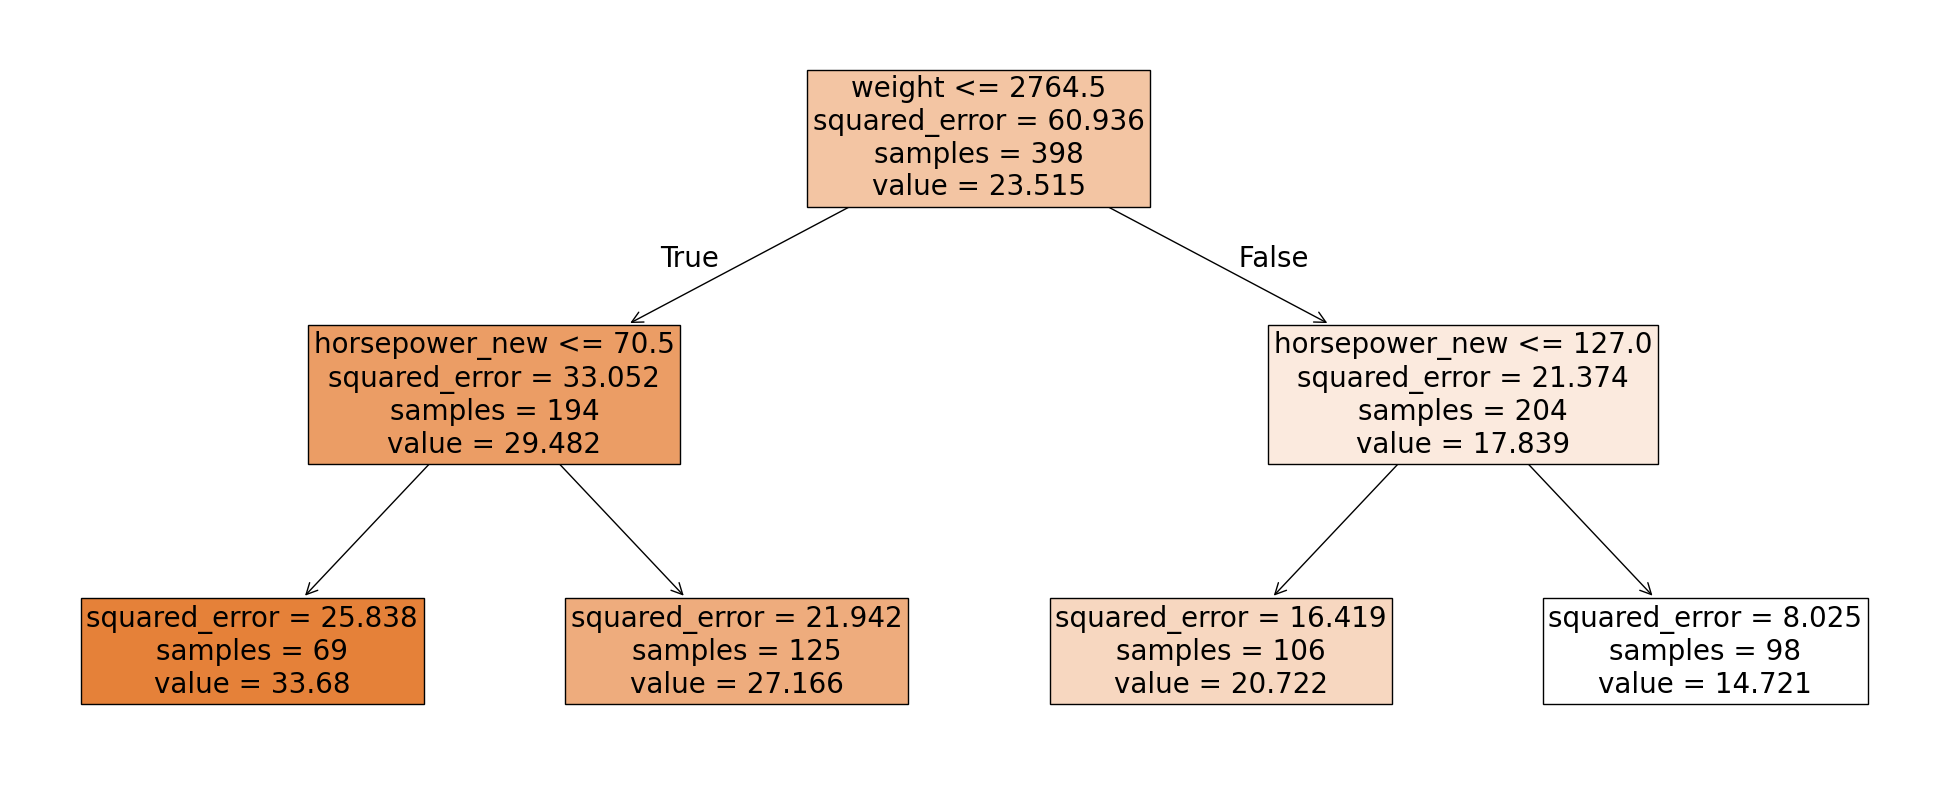

In [ ]:
plt.figure(figsize=(25,10))
model8=DecisionTreeRegressor(max_depth=2, min_samples_leaf=2).fit(X7,Y7)
tree.plot_tree(model8,feature_names=X7.columns,fontsize=20,filled=True)
plt.show()

## Дерево решений (Decision Tree) с аргументами

Y9=cars['mpg']


X9=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]

In [ ]:
Y9=cars['mpg']
X9=cars[['weight', 'horsepower_new','origin','displacement','cylinders', 'acceleration', 'model year']]
X9_train, X9_test, Y9_train, Y9_test=train_test_split(X9, Y9, test_size=0.2, random_state=0)
dtr=DecisionTreeRegressor(max_depth=4, min_samples_leaf=3)
model9=dtr.fit(X9_train,Y9_train)
Y9_train_pred=model9.predict(X9_train)
Y9_test_pred=model9.predict(X9_test)
Models.at[QualityMetrics, 'Decision Tree_full']=[r2_score(Y9_train, Y9_train_pred),
                                                 r2_score(Y9_test, Y9_test_pred),
                                                 mean_squared_error(Y9_train, Y9_train_pred),
                                                 mean_squared_error(Y9_test, Y9_test_pred)]
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Decision Tree,Decision Tree_full
R2 train,0.717131,0.799115,0.818790,0.887542,0.762210,0.866059,0.813091,0.887404
R2 test,0.712556,0.794545,0.820529,0.893278,0.705135,0.846344,0.631040,0.840413
MSE train,17.052417,15.454607,10.923995,8.148694,14.334855,8.074475,11.267587,6.787718
MSE test,18.240470,16.634592,11.388753,7.701879,18.711332,9.750598,23.413260,10.126998
Forecast,24.270000,21.760000,24.560000,21.510000,22.850000,21.760000,23.160000,NaN


In [ ]:
x_new_car=[[3000,100,2,200,5,17,76]]
y_new_car=model9.predict(x_new_car)
Models.at['Forecast','Decision Tree_full']=y_new_car.round(2)[0]
print('Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100, страной производителем -Европа, обьемом двигателя 200, количеством цилиндров в двигателе 5, разгоном 17 секунд и годом модели 76 ',y_new_car.round(2)[0])

Прогноз расхода топлива для автомобиля весом 3000, количеством лошадиных сил 100, страной производителем -Европа, обьемом двигателя 200, количеством цилиндров в двигателе 5, разгоном 17 секунд и годом модели 76  22.81


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
Models

,LinearRegressor,NonLinearRegressor,LinearRegressor_full,NonLinearRegressor_full,Polynomial Model,Polynomial Model_full,Decision Tree,Decision Tree_full
R2 train,0.717131,0.799115,0.818790,0.887542,0.762210,0.866059,0.813091,0.887404
R2 test,0.712556,0.794545,0.820529,0.893278,0.705135,0.846344,0.631040,0.840413
MSE train,17.052417,15.454607,10.923995,8.148694,14.334855,8.074475,11.267587,6.787718
MSE test,18.240470,16.634592,11.388753,7.701879,18.711332,9.750598,23.413260,10.126998
Forecast,24.270000,21.760000,24.560000,21.510000,22.850000,21.760000,23.160000,22.810000


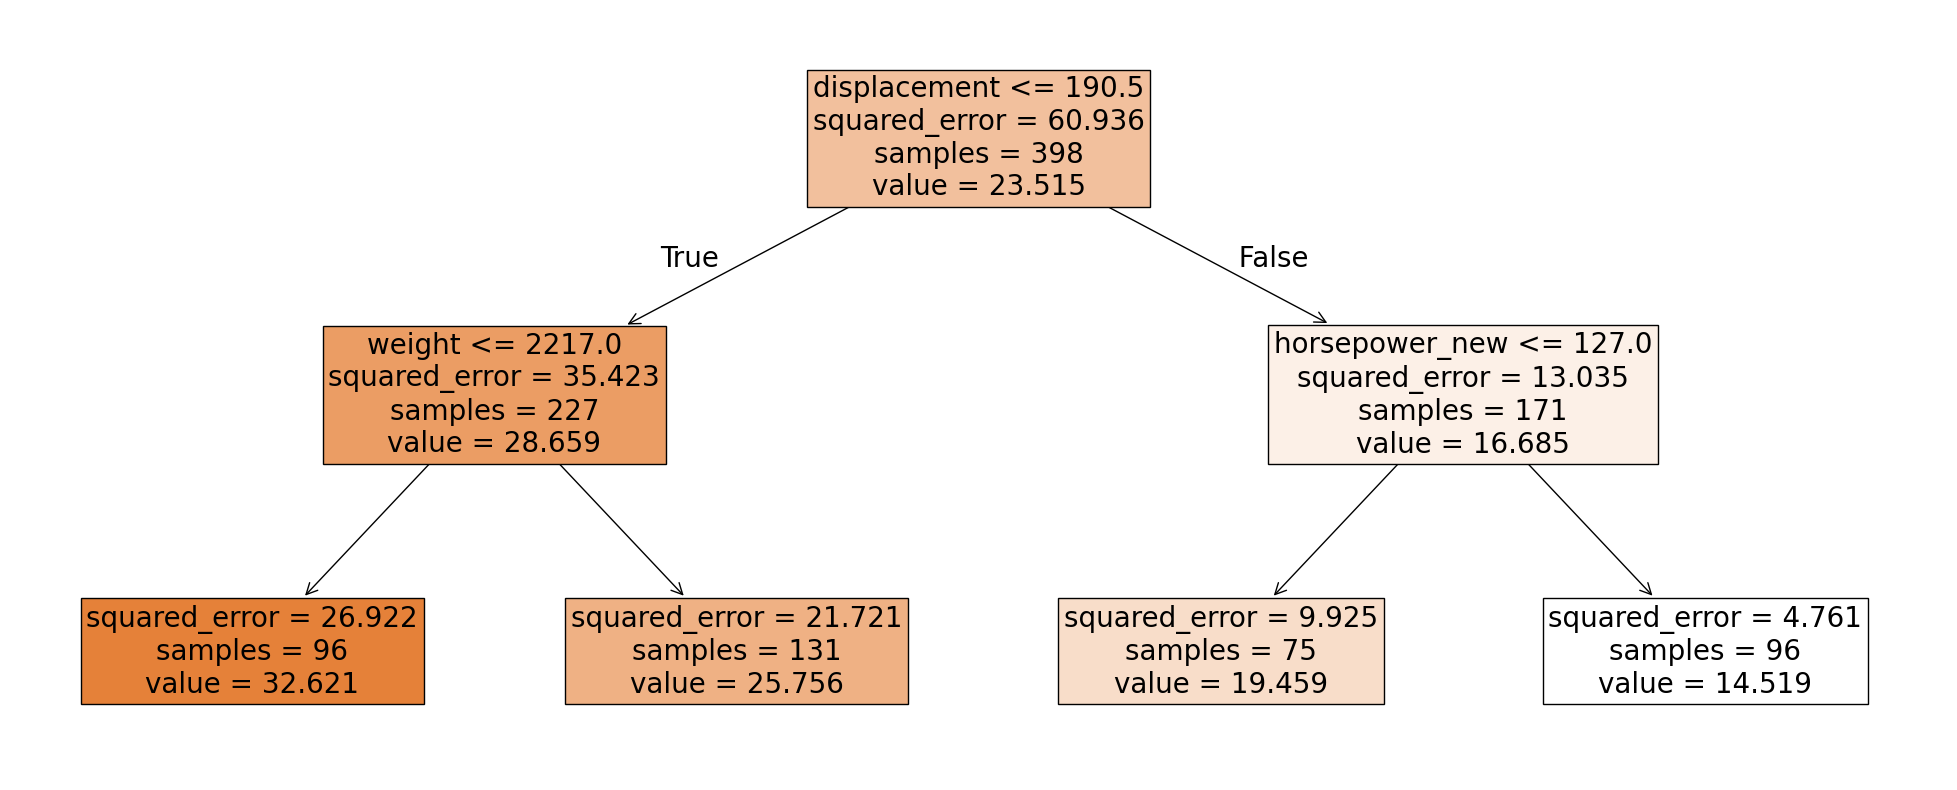

In [ ]:
plt.figure(figsize=(25,10))
model10=DecisionTreeRegressor(max_depth=2, min_samples_leaf=2).fit(X9,Y9)
tree.plot_tree(model10,feature_names=X9.columns,fontsize=20,filled=True)
plt.show()

## **Вывод:**
Лучше всего себя показали NonLinearRegressor_full, Polynomial Model_full,Decision Tree_full

Т к значения r2_score как для обучающей, так и для тестовой выборки самые высокие, по сравнению с другими моделями

Показатель MSE лучше всего себя показал на NonLinearRegressor_full модели

Поэтому предпочтительнее было бы использовать в дальнейшем исследовании именно нелинейную модель, приведенную к линейной с помощью метода линеаризации по аргументам :


Y3=cars['mpg1']


X3=cars[['weight1', 'displacement1','horsepower_new1','origin','cylinders', 'acceleration', 'model year']]